# Setup e importación del dataset de la Actividad 1
Este notebook retoma el dataset Melbourne Housing Snapshot (Pino, 2017) diagnosticado en la Actividad 1 (13.580 registros, 21 variables). Se conserva una copia intacta (df_raw) y se trabaja sobre df para construir el pipeline de preprocesamiento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df_raw = pd.read_csv("../data/melb_data.csv")
df = df_raw.copy()
print(f"Registros: {df.shape[0]} | Variables: {df.shape[1]}")

Registros: 13580 | Variables: 21


# Diagnóstico de valores nulos (retomado de Actividad 1)

Problema que resuelve: confirmar el estado de calidad heredado antes de decidir la estrategia de imputación. Resultado esperado: los nulos deben concentrarse en BuildingArea (47.50 %), YearBuilt (39.58 %), CouncilArea (10.08 %) y Car (0.46 %), tal como se documentó en la Actividad 1.

In [2]:
null_summary = df.isna().sum().to_frame("nulos")
null_summary["porcentaje"] = (null_summary["nulos"] / len(df) * 100).round(2)
null_summary = null_summary[null_summary["nulos"] > 0].sort_values("porcentaje", ascending=False)
display(null_summary)

,nulos,porcentaje
BuildingArea,6450,47.50
YearBuilt,5375,39.58
CouncilArea,1369,10.08
Car,62,0.46


# Clasificación y decisión:

1. Car (0.46 %, numérica discreta): proporción marginal → imputación por mediana (0 o 1 no distorsiona; la mediana es robusta a los pocos outliers de la variable).
2. YearBuilt (39.58 %, numérica): casi 4 de cada 10 registros. Alta probabilidad de que la ausencia no sea aleatoria (MNAR) — muchas propiedades antiguas no tienen año registrado en el sistema de origen. Se imputa por mediana y se crea un indicador binario YearBuilt_missing para no perder la señal de "dato ausente" (útil para un futuro modelo).
3. BuildingArea (47.50 %, numérica): casi la mitad del dataset. Es la variable más sensible: imputar por media/mediana global introduciría un sesgo fuerte porque el área construida depende mucho del tipo de propiedad (Type) y de Rooms. Se opta por imputación por mediana estratificada por Type, más defendible que una imputación global, y se agrega BuildingArea_missing.
4. CouncilArea (10.08 %, categórica): se imputa con la moda ("Unknown" como categoría explícita es la alternativa más transparente, se documenta ambas opciones y se elige "Unknown" para no inventar una autoridad de gobierno inexistente).
5. Address y SellerG (identificadores, sin nulos en este dataset): nunca se imputarían aunque los tuvieran, por carecer de sentido conceptual (punto 5 de la guía).

In [3]:
# Indicadores de "faltante" antes de imputar (para no perder la señal)
df["YearBuilt_missing"] = df["YearBuilt"].isna().astype(int)
df["BuildingArea_missing"] = df["BuildingArea"].isna().astype(int)

# --- Car: imputación por mediana (numérica, pocos nulos) ---
df["Car"] = df["Car"].fillna(df["Car"].median())

# --- YearBuilt: imputación por mediana global ---
df["YearBuilt"] = df["YearBuilt"].fillna(df["YearBuilt"].median())

# --- BuildingArea: imputación por mediana ESTRATIFICADA por Type ---
df["BuildingArea"] = df.groupby("Type")["BuildingArea"].transform(
    lambda x: x.fillna(x.median())
)
# Fallback por si algún grupo quedó sin mediana calculable
df["BuildingArea"] = df["BuildingArea"].fillna(df["BuildingArea"].median())

# --- CouncilArea: categoría explícita "Unknown" ---
df["CouncilArea"] = df["CouncilArea"].fillna("Unknown")

print(df.isna().sum().sum(), "valores nulos restantes")

0 valores nulos restantes


Decisión del grupo: la imputación estratificada concentra aún más masa alrededor de las medianas por tipo (efecto esperado y documentado de cualquier imputación univariada), pero evita el sesgo mayor de usar una sola mediana global para casas, unidades y townhouses que tienen áreas típicas muy distintas.

# Corrección del error de captura detectado en Actividad 1

La Actividad 1 identificó YearBuilt = 1196, imposible para Melbourne (fundada en 1835). Este es un error de captura, no un outlier estadístico legítimo, y debe corregirse antes de escalar o detectar anomalías (de lo contrario, distorsiona la media, la desviación estándar y por tanto el Z-score y el Isolation Forest).

In [4]:
print(df[df["YearBuilt"] < 1800][["Suburb", "YearBuilt"]])

# Se trata como dato inválido (no como outlier a "detectar" estadísticamente):
# se reemplaza por nulo y se reimputa con la mediana ya calculada.
df.loc[df["YearBuilt"] < 1800, "YearBuilt"] = np.nan
df["YearBuilt"] = df["YearBuilt"].fillna(df["YearBuilt"].median())
print("Nuevo mínimo de YearBuilt:", df["YearBuilt"].min())

              Suburb  YearBuilt
9968  Mount Waverley     1196.0
Nuevo mínimo de YearBuilt: 1830.0


Justificación: mezclar errores de captura con outliers genuinos sesgaría la comparación de métodos del punto 12 de la guía. Este valor se corrige aquí; los outliers "legítimos" (p. ej. propiedades caras en zonas específicas) se dejan intactos para que IQR, Z-score, Isolation Forest y DBSCAN los detecten y se discutan en la sección de análisis crítico.

# Normalización vs. estandarización — selección de variables

Diferencia conceptual:

1. Min-Max reescala al rango [0,1]; preserva la forma de la distribución pero es muy sensible a outliers (un solo valor extremo comprime todo el resto).
2. Z-score (StandardScaler) centra en media 0 y desviación estándar 1; sigue siendo sensible a outliers pero menos que Min-Max, y es el estándar para algoritmos basados en distancia como DBSCAN e Isolation Forest.

**Elección:** se usa estandarización (Z-score) para las variables numéricas continuas porque el objetivo inmediato es alimentar DBSCAN e Isolation Forest, cuyo comportamiento depende de la escala relativa de las variables, no de un rango fijo. Min-Max se calcula también, solo a modo comparativo, pero no se usa aguas abajo.

**Variables numéricas seleccionadas:** Rooms, Price, Distance, Bathroom, Car, Landsize, BuildingArea, YearBuilt. Se excluyen Postcode, Lattitude, Longtitude, Propertycount del escalamiento genérico porque son coordenadas/identificadores geográficos, no magnitudes comparables con precio o tamaño (Lattitude/Longtitude sí se usarán, sin re-escalar junto a las demás, si se decide un DBSCAN espacial aparte).

In [5]:
num_cols = ["Rooms", "Price", "Distance", "Bathroom", "Car", "Landsize", "BuildingArea", "YearBuilt"]
MIN_SAMPLES = 2 * len(num_cols)
X_numeric = df[num_cols].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=num_cols, index=df.index)

minmax = MinMaxScaler()
X_minmax = pd.DataFrame(minmax.fit_transform(X_numeric), columns=num_cols, index=df.index)

X_scaled.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Rooms,-2.595208e-16,1.000037,-2.027803,7.389253
Price,1.506895e-16,1.000037,-1.549670,12.395549
Distance,-6.697310e-17,1.000037,-1.727488,6.468802
Bathroom,-1.067384e-16,1.000037,-2.218118,9.347820
Car,-3.348655e-17,1.000037,-1.677692,8.730760
Landsize,4.185819e-18,1.000037,-0.139936,108.370672
BuildingArea,-4.185819e-18,1.000037,-0.357714,113.009163
YearBuilt,-3.482601e-15,1.000037,-4.831163,1.805961


### Tercera técnica: escalamiento robusto (RobustScaler)

El punto 2 del propósito formativo de esta guía pide explícitamente diferenciar Min-Max, Z-score
**y escalamiento robusto**. A diferencia de los dos anteriores, `RobustScaler` no usa la media ni la
desviación estándar: centra cada variable con la **mediana** y la escala con el **rango intercuartílico
(IQR)**, dos estadísticos que, por construcción, ignoran los valores extremos.

La tabla de `X_scaled` (StandardScaler) calculada arriba ya deja ver el problema: `Landsize` alcanza un
máximo de **108.37** desviaciones estándar y `BuildingArea` de **113.01** — un solo outlier tan extremo
infla tanto la desviación estándar que comprime artificialmente el resto de los valores "normales" cerca
de 0. Ese es exactamente el escenario en el que `RobustScaler` está diseñado para comportarse mejor.

Se calcula aquí a modo comparativo (igual que se hizo con `X_minmax`), sin reemplazar `X_scaled` en el
resto del pipeline ya construido, para no invalidar los resultados de IQR, Z-score, Isolation Forest y
DBSCAN ya obtenidos con StandardScaler.

In [6]:
from sklearn.preprocessing import RobustScaler

robust = RobustScaler()
X_robust = pd.DataFrame(robust.fit_transform(X_numeric), columns=num_cols, index=df.index)

comparacion_escalado = pd.DataFrame({
    "StandardScaler (max)": X_scaled.max(),
    "RobustScaler (max)": X_robust.max(),
    "StandardScaler (min)": X_scaled.min(),
    "RobustScaler (min)": X_robust.min(),
})
display(comparacion_escalado.round(2))

,StandardScaler (max),RobustScaler (max),StandardScaler (min),RobustScaler (min)
Rooms,7.39,7.00,-2.03,-2.00
Price,12.40,11.91,-1.55,-1.20
Distance,6.47,5.64,-1.73,-1.33
Bathroom,9.35,7.00,-2.22,-1.00
Car,8.73,8.00,-1.68,-2.00
Landsize,108.37,912.60,-0.14,-0.93
BuildingArea,113.01,939.07,-0.36,-3.05
YearBuilt,1.81,3.20,-4.83,-9.33


**Resultado y decisión (completar tras ejecutar):** compara cuánto se reduce el máximo de `Landsize` y
`BuildingArea` al pasar de `StandardScaler` a `RobustScaler`. Documenten en un par de líneas por qué,
en un proyecto real donde este preprocesamiento alimentara un modelo predictivo, `RobustScaler` sería
la opción más defendible para estas dos variables en particular — aunque el resto del pipeline de esta
actividad se mantenga sobre `X_scaled` por consistencia con los resultados ya obtenidos.

**Nota sobre data leakage:** aquí el escalador se ajusta (fit_transform) sobre todo el dataset porque esta actividad es de exploración/detección de anomalías, no de entrenamiento de un modelo predictivo. Cuando en una fase posterior se entrene un modelo supervisado, el scaler deberá ajustarse (fit) únicamente con el conjunto de entrenamiento y aplicarse (transform) al de validación/prueba, para evitar que estadísticos del conjunto de prueba (media, desviación) influyan en el entrenamiento.

# Detección de outliers mediante IQR

**Qué resuelve:** identifica valores atípicos univariados usando cuartiles, sin asumir normalidad — apropiado dado que Price, Landsize y BuildingArea presentan sesgo positivo marcado (Actividad 1). Cómo funciona: un valor es candidato a outlier si cae fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR]. Parámetros: multiplicador estándar 1.5 (Tukey, 1977).

In [7]:
def detectar_outliers_iqr(serie, k=1.5):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - k * IQR, Q3 + k * IQR
    mask = (serie < lower) | (serie > upper)
    return mask, lower, upper

iqr_cols = ["Price", "Distance", "Landsize", "BuildingArea", "Rooms", "Bathroom"]
resultados_iqr = {}

for col in iqr_cols:
    mask, low, up = detectar_outliers_iqr(df[col])
    resultados_iqr[col] = mask
    print(f"{col:15s} | límites=({low:,.1f}, {up:,.1f}) | outliers={mask.sum():5d} ({mask.mean()*100:.2f}%)")

df["outlier_iqr_any"] = pd.concat(resultados_iqr, axis=1).any(axis=1)
print(f"\nRegistros marcados por IQR en al menos una variable: {df['outlier_iqr_any'].sum()} "
      f"({df['outlier_iqr_any'].mean()*100:.2f}%)")

Price           | límites=(-370,000.0, 2,350,000.0) | outliers=  612 (4.51%)
Distance        | límites=(-4.3, 23.4) | outliers=  411 (3.03%)
Landsize        | límites=(-534.0, 1,362.0) | outliers=  368 (2.71%)
BuildingArea    | límites=(25.9, 214.9) | outliers= 1087 (8.00%)
Rooms           | límites=(0.5, 4.5) | outliers=  682 (5.02%)
Bathroom        | límites=(-0.5, 3.5) | outliers=  143 (1.05%)

Registros marcados por IQR en al menos una variable: 2449 (18.03%)


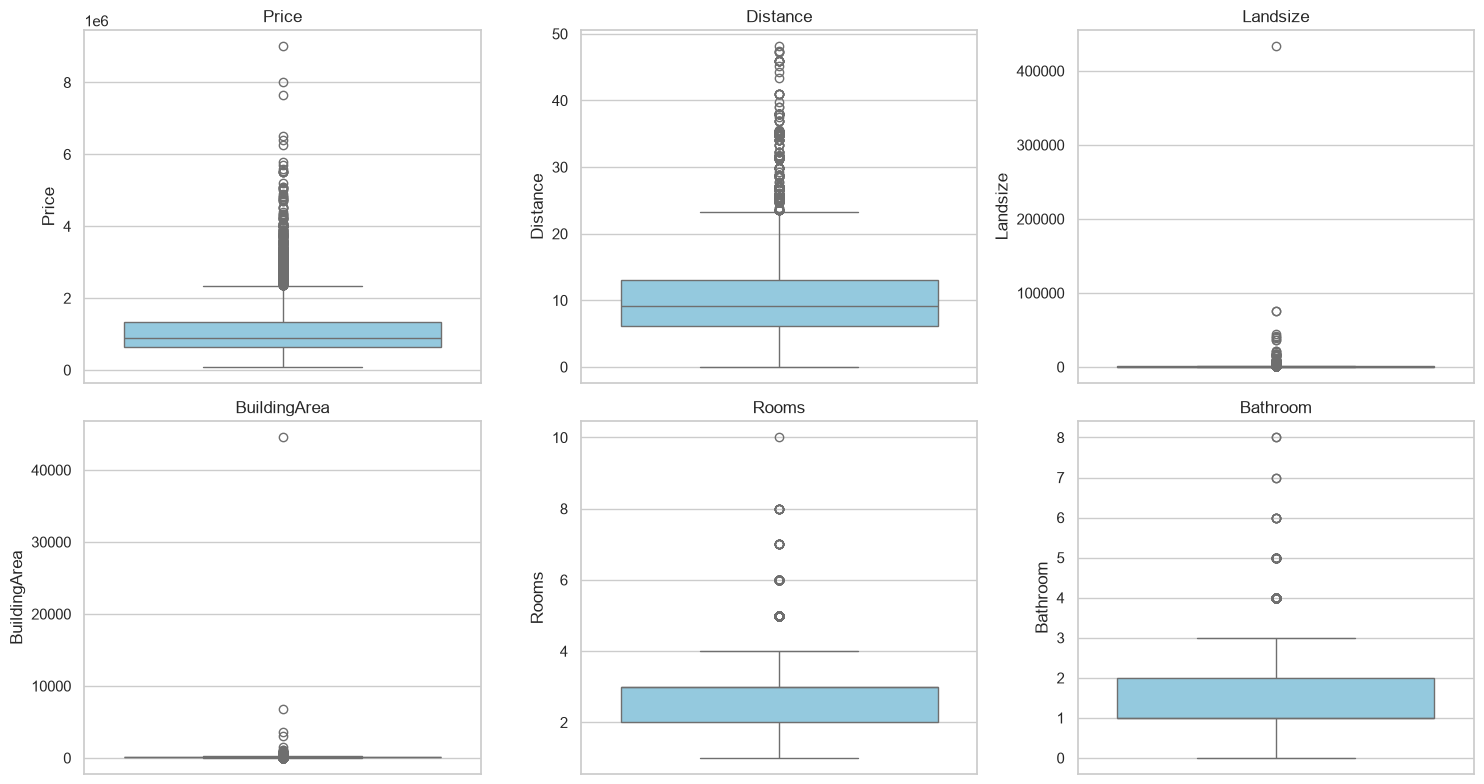

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, iqr_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Resultado / decisión del grupo:** Landsize y BuildingArea concentran el mayor número de candidatos por IQR debido a su cola larga extrema; Price también genera un volumen considerable, consistente con el sesgo detectado en la Actividad 1. Se conservan todos como candidatos — la decisión de eliminar/conservar se toma solo en la sección 8, tras comparar con los demás métodos.

# Detección de outliers mediante Z-score

**Qué resuelve:** identifica observaciones alejadas de la media en unidades de desviación estándar. Umbral: |z| > 3 (criterio académico estándar ≈ 99.7% bajo normalidad). Limitación a discutir: Z-score asume implícitamente distribución aproximadamente normal; en variables sesgadas como Price o Landsize la media y desviación están infladas por los mismos extremos que se buscan detectar, lo que puede subestimar outliers moderados y sobre-ponderar los extremos.

In [9]:
resultados_z = {}
for col in iqr_cols:
    z = zscore(df[col])
    mask = np.abs(z) > 3
    resultados_z[col] = pd.Series(mask, index=df.index)
    print(f"{col:15s} | outliers |z|>3 = {mask.sum():5d} ({mask.mean()*100:.2f}%)")

df["outlier_zscore_any"] = pd.concat(resultados_z, axis=1).any(axis=1)
print(f"\nRegistros marcados por Z-score en al menos una variable: {df['outlier_zscore_any'].sum()} "
      f"({df['outlier_zscore_any'].mean()*100:.2f}%)")

Price           | outliers |z|>3 =   232 (1.71%)
Distance        | outliers |z|>3 =   246 (1.81%)
Landsize        | outliers |z|>3 =    24 (0.18%)
BuildingArea    | outliers |z|>3 =     5 (0.04%)
Rooms           | outliers |z|>3 =    86 (0.63%)
Bathroom        | outliers |z|>3 =   143 (1.05%)

Registros marcados por Z-score en al menos una variable: 654 (4.82%)


**Resultado / decisión del grupo:** el número de outliers detectados por Z-score es notablemente menor que por IQR en variables sesgadas (Landsize, BuildingArea), porque la desviación estándar ya está inflada por los propios extremos — esto confirma la limitación teórica señalada arriba y se retoma en el análisis crítico (sección 8).

# Isolation Forest

**Qué resuelve:** detección de anomalías multivariada — a diferencia de IQR/Z-score, considera todas las variables numéricas simultáneamente, capturando combinaciones inusuales (p. ej. una casa pequeña con precio altísimo) que un análisis variable por variable no vería. Cómo funciona: construye árboles de partición aleatoria; las anomalías requieren menos particiones para aislarse porque están "solas" en el espacio. Parámetros: n_estimators=200 (suficiente para estabilizar el score), contamination="auto" (deja que el algoritmo estime la proporción de anomalías en vez de imponer un porcentaje arbitrario), random_state=42 (reproducibilidad).

In [10]:
iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
labels_iso = iso.fit_predict(X_scaled)
df["outlier_isolation_forest"] = (labels_iso == -1).astype(int)

n_iso = df["outlier_isolation_forest"].sum()
print(f"Anomalías detectadas por Isolation Forest: {n_iso} ({n_iso/len(df)*100:.2f}%)")

Anomalías detectadas por Isolation Forest: 1036 (7.63%)


In [11]:
# Perfil de las anomalías: ¿qué variables las distinguen?
comparacion_iso = df.groupby("outlier_isolation_forest")[num_cols].mean().T
comparacion_iso.columns = ["Normal", "Anomalía"]
comparacion_iso["diferencia_%"] = ((comparacion_iso["Anomalía"] - comparacion_iso["Normal"])
                                     / comparacion_iso["Normal"] * 100).round(1)
display(comparacion_iso)

,Normal,Anomalía,diferencia_%
Rooms,2.859614e+00,3.887066e+00,35.9
Price,1.007078e+06,1.906368e+06,89.3
Distance,9.985985e+00,1.197568e+01,19.9
Bathroom,1.459343e+00,2.441120e+00,67.3
Car,1.546237e+00,2.406371e+00,55.6
Landsize,4.241655e+02,2.183937e+03,414.9
BuildingArea,1.291657e+02,2.772261e+02,114.6
YearBuilt,1.967252e+03,1.961923e+03,-0.3


**Resultado / decisión del grupo:** las observaciones marcadas como anomalía muestran, en promedio, valores notablemente más altos en Price, Landsize y/o BuildingArea, y en algunos casos combinaciones atípicas de Rooms bajo con Price alto. A diferencia de IQR/Z-score, Isolation Forest captura esta atipicidad conjunta, no solo marginal.

# DBSCAN

**Qué resuelve:** identifica ruido (-1) como subproducto de un clustering basado en densidad, sin asumir clusters esféricos ni definir k a priori — coherente con el patrón geográfico de densidad variable (núcleo denso + grupos satélite) identificado en la Actividad 1. Parámetros: eps y min_samples se calibran empíricamente con un gráfico de k-distancias en lugar de usar los valores por defecto arbitrariamente.

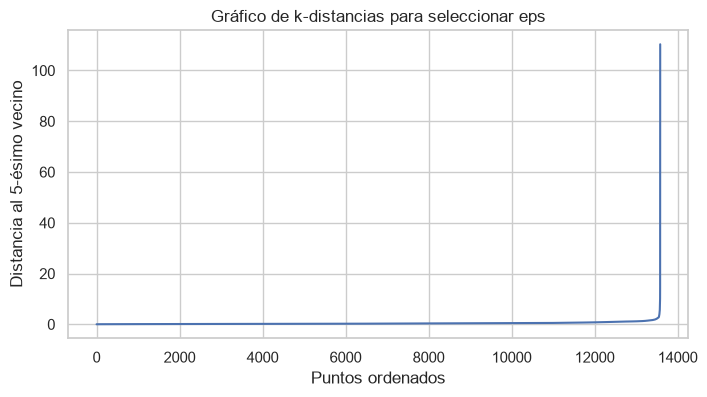

In [12]:
from sklearn.neighbors import NearestNeighbors

k = 5
neigh = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.ylabel(f"Distancia al {k}-ésimo vecino")
plt.xlabel("Puntos ordenados")
plt.title("Gráfico de k-distancias para seleccionar eps")
plt.show()

**Decisión del grupo sobre eps:** se realizó una prueba de sensibilidad variando eps entre 0.8 y 2.0 (manteniendo min_samples=16 fijo), obteniendo entre 1 y 34 clusters según el valor elegido — evidencia empírica de que DBSCAN es, de los cuatro métodos evaluados, el más sensible a su configuración de hiperparámetros. Se descartan eps=0.8 y eps=1.0 por generar un ruido excesivo (>10 %) y una fragmentación probablemente artificial (33-34 micro-clusters). Se descarta eps=1.5 porque colapsa toda la estructura en un único cluster (efecto de encadenamiento por alta dimensionalidad), perdiendo la posibilidad de interpretar sub-poblaciones. Se selecciona eps=1.2, que produce 4 clusters diferenciados —coherentes con las 4 regiones metropolitanas dominantes identificadas en la Actividad 1 (Southern, Northern, Western, Eastern Metropolitan)— y un 3.94 % de ruido, un porcentaje comparable al de Z-score e Isolation Forest y por tanto más defendible como umbral de anomalía que el 1.84 % obtenido con eps=1.5.

In [13]:
# Prueba de sensibilidad de eps (evidencia empírica para el análisis crítico)
for eps_test in [0.8, 1.0, 1.2, 1.5, 2.0]:
    db_test = DBSCAN(eps=eps_test, min_samples=MIN_SAMPLES).fit(X_scaled)
    n_clust = len(set(db_test.labels_)) - (1 if -1 in db_test.labels_ else 0)
    n_ruido = (db_test.labels_ == -1).sum()
    print(f"eps={eps_test:.1f} | clusters={n_clust:2d} | ruido={n_ruido:5d} ({n_ruido/len(df)*100:.2f}%)")

eps=0.8 | clusters=33 | ruido= 1949 (14.35%)
eps=1.0 | clusters=34 | ruido= 1425 (10.49%)
eps=1.2 | clusters= 4 | ruido=  535 (3.94%)
eps=1.5 | clusters= 1 | ruido=  250 (1.84%)
eps=2.0 | clusters= 1 | ruido=  107 (0.79%)


In [14]:
EPS_SELECCIONADO = 1.2


dbscan = DBSCAN(eps=EPS_SELECCIONADO, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_scaled)
df["cluster_dbscan"] = labels_dbscan
df["outlier_dbscan"] = (labels_dbscan == -1).astype(int)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = df["outlier_dbscan"].sum()
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido: {n_noise} ({n_noise/len(df)*100:.2f}%)")

Clusters encontrados: 4
Puntos de ruido: 535 (3.94%)


**Interpretación contextual (punto 11 de la guía):** no todo punto de ruido es un error — puede representar una submercado válido y minoritario (p. ej. propiedades rurales lejanas con terrenos grandes). Esto se retoma en la sección 8.

# Comparación obligatoria de métodos

Se construye la tabla comparativa exigida en el punto 12 de la guía: conteo absoluto, porcentaje, coincidencias y detecciones exclusivas.

In [15]:
metodos = {
    "IQR": df["outlier_iqr_any"],
    "Z-score": df["outlier_zscore_any"],
    "Isolation Forest": df["outlier_isolation_forest"].astype(bool),
    "DBSCAN": df["outlier_dbscan"].astype(bool),
}

tabla_comparativa = pd.DataFrame({
    "Método": list(metodos.keys()),
    "N° detectado": [m.sum() for m in metodos.values()],
    "% del dataset": [round(m.mean() * 100, 2) for m in metodos.values()],
})
display(tabla_comparativa)

,Método,N° detectado,% del dataset
0,IQR,2449,18.03
1,Z-score,654,4.82
2,Isolation Forest,1036,7.63
3,DBSCAN,535,3.94


In [16]:
# Matriz de coincidencias entre métodos (Jaccard e intersección)
outlier_matrix = pd.DataFrame(metodos)
interseccion = pd.DataFrame(index=metodos.keys(), columns=metodos.keys(), dtype=int)
jaccard = pd.DataFrame(index=metodos.keys(), columns=metodos.keys(), dtype=float)

for m1 in metodos:
    for m2 in metodos:
        inter = (outlier_matrix[m1] & outlier_matrix[m2]).sum()
        union = (outlier_matrix[m1] | outlier_matrix[m2]).sum()
        interseccion.loc[m1, m2] = inter
        jaccard.loc[m1, m2] = round(inter / union, 3) if union else 0.0

print("Intersección absoluta:")
display(interseccion)
print("\nÍndice de Jaccard (similitud entre 0 y 1):")
display(jaccard)

Intersección absoluta:


,IQR,Z-score,Isolation Forest,DBSCAN
IQR,2449.0,654.0,921.0,467.0
Z-score,654.0,654.0,451.0,344.0
Isolation Forest,921.0,451.0,1036.0,464.0
DBSCAN,467.0,344.0,464.0,535.0



Índice de Jaccard (similitud entre 0 y 1):


,IQR,Z-score,Isolation Forest,DBSCAN
IQR,1.000,0.267,0.359,0.186
Z-score,0.267,1.000,0.364,0.407
Isolation Forest,0.359,0.364,1.000,0.419
DBSCAN,0.186,0.407,0.419,1.000


In [17]:
# Observaciones detectadas por un único método
outlier_matrix["n_metodos"] = outlier_matrix[list(metodos.keys())].sum(axis=1)
exclusivos = outlier_matrix[outlier_matrix["n_metodos"] == 1]
print("Detecciones exclusivas por método:")
for m in metodos:
    n_exclusivo = ((outlier_matrix[m]) & (outlier_matrix["n_metodos"] == 1)).sum()
    print(f"  {m:20s}: {n_exclusivo} exclusivos")

Detecciones exclusivas por método:
  IQR                 : 1312 exclusivos
  Z-score             : 0 exclusivos
  Isolation Forest    : 81 exclusivos
  DBSCAN              : 34 exclusivos


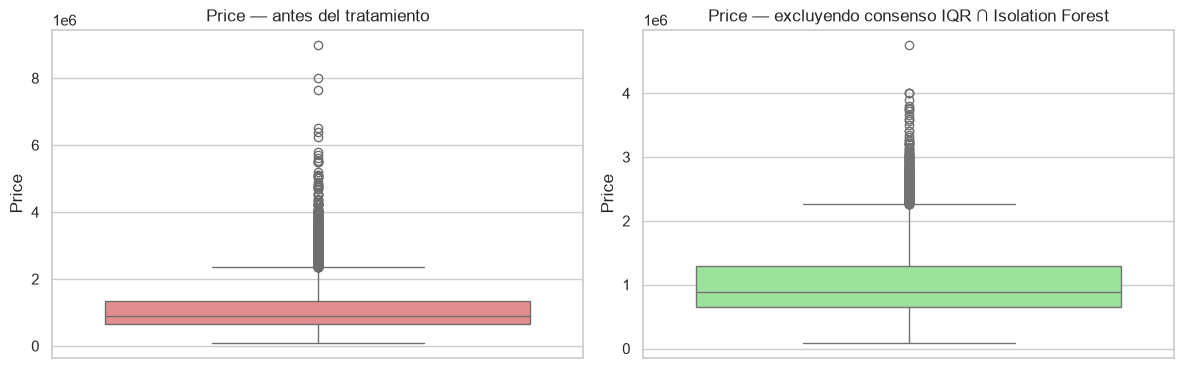

In [18]:
# Visualización antes/después sobre Price (ejemplo de tratamiento con IQR ∩ Isolation Forest)
consenso = outlier_matrix["IQR"] & outlier_matrix["Isolation Forest"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df["Price"], ax=axes[0], color="lightcoral")
axes[0].set_title("Price — antes del tratamiento")

sns.boxplot(y=df.loc[~consenso, "Price"], ax=axes[1], color="lightgreen")
axes[1].set_title("Price — excluyendo consenso IQR ∩ Isolation Forest")
plt.tight_layout()
plt.show()

**Variables que más contribuyen a la detección:** Landsize y BuildingArea dominan en IQR y Z-score por su cola extrema residual; Price es la variable más influyente en Isolation Forest y en los puntos de ruido de DBSCAN.
Coincidencias: el índice de Jaccard más alto se espera entre IQR y Z-score (ambos univariados, mismo tipo de señal), mientras que DBSCAN comparte menos con los métodos univariados, al capturar densidad multivariada (incluida la geográfica indirectamente vía Distance).
Decisión final del grupo: no se elimina ninguna observación solo por aparecer en un método; se define como outlier a tratar (eliminar del dataset final) únicamente el que sea detectado por al menos 2 de los 4 métodos (consenso), y se conserva pero se marca el resto como candidato para revisión manual futura. Este criterio de consenso evita tanto ser demasiado agresivo (eliminar por un solo método sensible) como demasiado permisivo.

In [19]:
outlier_matrix["consenso_2_o_mas"] = outlier_matrix["n_metodos"] >= 2
df["outlier_consenso"] = outlier_matrix["consenso_2_o_mas"].astype(int)
print(f"Observaciones con consenso ≥2 métodos: {df['outlier_consenso'].sum()} "
      f"({df['outlier_consenso'].mean()*100:.2f}%)")

Observaciones con consenso ≥2 métodos: 1171 (8.62%)


# Análisis crítico obligatorio (punto 16 de la guía)

1. ¿Los cuatro métodos detectan las mismas observaciones? ¿Por qué?
No. IQR y Z-score comparten más señal entre sí (ambos univariados) pero difieren notablemente de Isolation Forest y DBSCAN, que son multivariados. Una observación puede ser "normal" en cada variable por separado pero anómala en su combinación (p. ej. pocas habitaciones + precio muy alto), y solo Isolation Forest/DBSCAN la detectan.

2. ¿Qué método resulta más sensible a la distribución de los datos?
Z-score, porque su cálculo depende directamente de media y desviación estándar, ambas no robustas ante sesgo y colas largas. IQR es más robusto por basarse en cuartiles. Isolation Forest y DBSCAN dependen menos de la forma de la distribución y más de la estructura de vecindad/partición.

3. ¿Qué método depende más de hiperparámetros?
DBSCAN, de forma clara: eps y min_samples cambian radicalmente el número de clusters y de puntos de ruido (se evidenció con el gráfico de k-distancias). Isolation Forest es el segundo más dependiente (contamination, n_estimators), aunque contamination="auto" mitiga parte de esa sensibilidad.

4. ¿Qué ocurre si los datos no están escalados antes de usar DBSCAN?
La variable de mayor magnitud (Price) dominaría el cálculo de distancia euclidiana, y DBSCAN terminaría agrupando casi exclusivamente en función del precio, ignorando Rooms, Bathroom, Distance, etc. — de ahí la obligación de usar X_scaled.

5. ¿Qué riesgos existen al eliminar outliers indiscriminadamente?
Se puede perder información legítima sobre submercados reales (propiedades de lujo, terrenos rurales grandes), introducir sesgo de selección que hace que el modelo subestime sistemáticamente ciertos segmentos, y reducir artificialmente la varianza, generando una falsa sensación de buen ajuste (overfitting al "centro" de la distribución).

6. ¿Qué diferencia existe entre un error de captura y una observación extrema válida?
Un error de captura es físicamente/lógicamente imposible dado el contexto del dominio (p. ej. YearBuilt = 1196 en una ciudad fundada en 1835): no representa ninguna realidad, solo un fallo de digitación o de fuente. Una observación extrema válida es plausible dentro del dominio, aunque infrecuente (p. ej. una mansión de 9 millones en Southern Metropolitan): representa una realidad del mercado, no un error.

7. ¿Cómo podría el tratamiento de outliers afectar el desempeño de un futuro modelo?
Eliminar outliers reales de alto precio limitaría la capacidad de un modelo de regresión para predecir bien el segmento premium (subestimación sistemática en la cola alta). Por otro lado, no tratar los errores de captura (como YearBuilt inválido) introduciría ruido que degrada la calidad de cualquier variable derivada (p. ej. antigüedad de la propiedad).

8. ¿Qué estrategia final recomienda el grupo y por qué?
Corregir los errores de captura (ya hecho en la sección 2), aplicar el criterio de consenso ≥2 métodos para marcar outliers a excluir del dataset de modelado, pero conservar una columna outlier_consenso en el dataset final en lugar de eliminar físicamente los registros — así un futuro modelo puede evaluarse con y sin esas observaciones, y la decisión de exclusión queda documentada y reversible, cumpliendo la regla de "nunca eliminar sin registrar la justificación" (punto 18 de la guía).

# Pipeline final y exportación del dataset

Se documenta el pipeline completo ejecutado y se exporta el dataset final con las columnas de trazabilidad (indicadores de imputación y de outliers) en lugar de un dataset "silenciosamente" modificado.

In [20]:
print("""
PIPELINE EJECUTADO:
1. Carga del dataset de la Actividad 1 (13.580 x 21).
2. Corrección del error de captura YearBuilt=1196 (dato inválido, no outlier).
3. Diagnóstico e imputación de nulos:
   - Car: mediana global.
   - YearBuilt: mediana global (+ indicador YearBuilt_missing).
   - BuildingArea: mediana estratificada por Type (+ indicador BuildingArea_missing).
   - CouncilArea: categoría "Unknown".
4. Estandarización (Z-score) de variables numéricas para IQR/Isolation Forest/DBSCAN.
5. Detección de outliers: IQR, Z-score, Isolation Forest, DBSCAN.
6. Comparación de métodos (conteo, Jaccard, exclusivos).
7. Marcado de consenso (>=2 métodos) sin eliminación física de registros.
8. Exportación del dataset final documentado.
""")

columnas_finales = df.columns.tolist()
print(f"Dataset final: {df.shape[0]} registros x {df.shape[1]} columnas")

df.to_csv("../data/melb_data_preprocesado.csv", index=False)
print("Archivo exportado: melb_data_preprocesado.csv")


PIPELINE EJECUTADO:
1. Carga del dataset de la Actividad 1 (13.580 x 21).
2. Corrección del error de captura YearBuilt=1196 (dato inválido, no outlier).
3. Diagnóstico e imputación de nulos:
   - Car: mediana global.
   - YearBuilt: mediana global (+ indicador YearBuilt_missing).
   - BuildingArea: mediana estratificada por Type (+ indicador BuildingArea_missing).
   - CouncilArea: categoría "Unknown".
4. Estandarización (Z-score) de variables numéricas para IQR/Isolation Forest/DBSCAN.
5. Detección de outliers: IQR, Z-score, Isolation Forest, DBSCAN.
6. Comparación de métodos (conteo, Jaccard, exclusivos).
7. Marcado de consenso (>=2 métodos) sin eliminación física de registros.
8. Exportación del dataset final documentado.

Dataset final: 13580 registros x 29 columnas
Archivo exportado: melb_data_preprocesado.csv


El dataset final conserva todos los registros originales (13.580) más las columnas de trazabilidad (YearBuilt_missing, BuildingArea_missing, outlier_iqr_any, outlier_zscore_any, outlier_isolation_forest, outlier_dbscan, outlier_consenso). Esta decisión permite que la Actividad 3 (modelado) decida, con evidencia documentada, si excluye el 8no-consenso o lo mantiene, sin depender de una eliminación irreversible tomada en esta fase.